In [14]:
!pip install kagglehub -q
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
path = kagglehub.dataset_download("rashmiranu/banking-dataset-classification")

#map
train_path = os.path.join(path, 'new_train.csv')
test_path = os.path.join(path, 'new_test.csv')

#load
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

#Drop the  duration column:  prevent data bias-(long calls, higher yes)
#2. how could one predict duration before call
if 'duration' in train_df.columns:
    train_df = train_df.drop('duration', axis=1)
if 'duration' in test_df.columns:
    test_df = test_df.drop('duration', axis=1)

#check1
#train_df.head()



Using Colab cache for faster access to the 'banking-dataset-classification' dataset.


Missing Values Check
age            0
job            0
marital        0
education      0
default        0
housing        0
loan           0
contact        0
month          0
day_of_week    0
campaign       0
pdays          0
previous       0
poutcome       0
y              0
dtype: int64


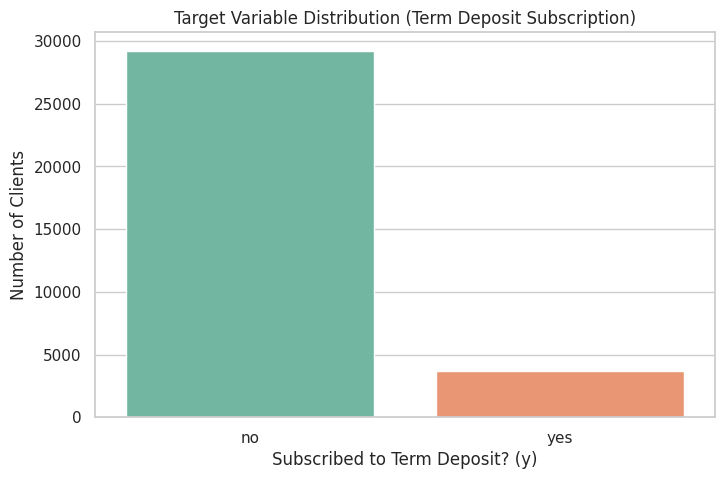


Exact Breakdown:
Percentage of clients who said 'yes': 11.27%
Percentage of clients who said 'no': 88.73%


In [15]:
#EDA
#check2
print("Missing Values Check")
print(train_df.isnull().sum())


#  class imbalance
plt.figure(figsize=(8, 5))
sns.countplot(data=train_df, x='y', hue='y', palette='Set2')
plt.title('Target Variable Distribution (Term Deposit Subscription)')
plt.xlabel('Subscribed to Term Deposit? (y)')
plt.ylabel('Number of Clients')
plt.show()

#  print the  percentage of the imbalance
yes_count = (train_df['y'] == 'yes').sum()
no_count = (train_df['y'] == 'no').sum()
total = len(train_df)

print(f"\nExact Breakdown:")
print(f"Percentage of clients who said 'yes': {(yes_count/total)*100:.2f}%")
print(f"Percentage of clients who said 'no': {(no_count/total)*100:.2f}%")

In [16]:
#data preprocessing

#scaling lib
from sklearn.preprocessing import StandardScaler

# feature-target separated
X_train = train_df.drop('y', axis=1)
y_train = train_df['y']

#test features
X_test = test_df.copy()

# binary logic (1 for 'yes', 0 for 'no')
y_train = y_train.map({'yes': 1, 'no': 0})

X_train_encoded = pd.get_dummies(X_train, drop_first=True) #predictable so drop
X_test_encoded = pd.get_dummies(X_test, drop_first=True)

#check3
#both train and test sets have the exact same columns after encoding
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_encoded), columns=X_train_encoded.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_encoded), columns=X_test_encoded.columns)

#check4
print("--- Preprocessing Complete! ---")
print(f"Number of features before encoding: {X_train.shape[1]}")
print(f"Number of features after encoding: {X_train_scaled.shape[1]}")

--- Preprocessing Complete! ---
Number of features before encoding: 14
Number of features after encoding: 47


In [17]:
# balance data
from imblearn.over_sampling import SMOTE

# Initialize SMOTE
#Synthetic Minority Oversampling Technique
smote = SMOTE(random_state=42)

# Apply SMOTE to training data
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

print("--- Data Balancing Complete! ---")
print(f"Original 'yes' clients: {(y_train == 1).sum()}")
print(f"Original 'no' clients: {(y_train == 0).sum()}")
print("-" * 30)
print(f"Balanced 'yes' clients: {(y_train_balanced == 1).sum()}")
print(f"Balanced 'no' clients: {(y_train_balanced == 0).sum()}")

--- Data Balancing Complete! ---
Original 'yes' clients: 3712
Original 'no' clients: 29238
------------------------------
Balanced 'yes' clients: 29238
Balanced 'no' clients: 29238


In [18]:
#validation testing
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split

# Split (80% for training, 20% for testing)
X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_balanced, y_train_balanced, test_size=0.2, random_state=42
)

# Initialize the Random Forest model
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Train the model
rf_model.fit(X_train_final, y_train_final)

# Make predictions on the hidden 20%
val_predictions = rf_model.predict(X_val)


print("\n Model Evaluation Report ")
print(classification_report(y_val, val_predictions, target_names=['No (0)', 'Yes (1)']))

#precision-> high=fewer wasted calls {true/positives}
#recall-> high=fewer missed business opportunities. {TP/TP+FN}
#F1-Score-> mathematical balance (harmonic mean) between Precision and Recall
#support-> It shows you exactly how many true 'Yes' and true 'No' records the model was tested against
#Overall Accuracy-> Out of all the predictions the model made (both 'Yes' and 'No'), what percentage was entirely correct {TP+TN/ALL}


 Model Evaluation Report 
              precision    recall  f1-score   support

      No (0)       0.92      0.96      0.94      5766
     Yes (1)       0.96      0.92      0.94      5930

    accuracy                           0.94     11696
   macro avg       0.94      0.94      0.94     11696
weighted avg       0.94      0.94      0.94     11696



In [19]:
#testing data test random forest
final_predictions = rf_model.predict(X_test_scaled)


#  mapping the 1s and 0s back to 'yes' and 'no' s
submission_df = pd.DataFrame({
    'Client_Index': test_df.index,
    'Predicted_Subscription': ['yes' if pred == 1 else 'no' for pred in final_predictions]
})


submission_filename = 'marketing_target_predictions.csv'
submission_df.to_csv(submission_filename, index=False)


print(f"Successfully generated predictions for all {len(submission_df)} unseen clients.")
print(f"Results saved to: {submission_filename}\n")

#print("preview(10 rows) of the final marketing list:")
#display(submission_df.head(11))

Successfully generated predictions for all 8238 unseen clients.
Results saved to: marketing_target_predictions.csv



In [20]:
# Logistic Regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Initialize the transparent scoring model
# We set max_iter=1000 to give the algorithm enough time to calculate the perfect weights
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model on our balanced 80% data vault
lr_model.fit(X_train_final, y_train_final)

# Make predictions on the hidden 20% validation set
lr_val_predictions = lr_model.predict(X_val)

# Generate the Business Report Card!
print("\n Logistic Regression Evaluation Report ")
print(classification_report(y_val, lr_val_predictions, target_names=['No (0)', 'Yes (1)']))


 Logistic Regression Evaluation Report 
              precision    recall  f1-score   support

      No (0)       0.66      0.80      0.72      5766
     Yes (1)       0.76      0.61      0.67      5930

    accuracy                           0.70     11696
   macro avg       0.71      0.70      0.70     11696
weighted avg       0.71      0.70      0.70     11696



In [21]:
# Logistic Regression Predictions

# the hidden Kaggle test data
lr_final_predictions = lr_model.predict(X_test_scaled)

# Map the 1s and 0s back to 'yes' and 'no'
lr_submission_df = pd.DataFrame({
    'Client_Index': test_df.index,
    'Predicted_Subscription': ['yes' if pred == 1 else 'no' for pred in lr_final_predictions]
})

# save to a csv file
lr_submission_filename = 'logistic_regression_predictions.csv'
lr_submission_df.to_csv(lr_submission_filename, index=False)

print(f"Successfully generated Logistic Regression predictions for {len(lr_submission_df)} clients.")
print(f"Results saved to: {lr_submission_filename}")

Successfully generated Logistic Regression predictions for 8238 clients.
Results saved to: logistic_regression_predictions.csv


In [22]:
# XGBoost classifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# random_state for reproducibility
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Train model
xgb_model.fit(X_train_final, y_train_final)

# Make predictions
xgb_val_predictions = xgb_model.predict(X_val)


print("\n XGBoost Evaluation Report ")
print(classification_report(y_val, xgb_val_predictions, target_names=['No (0)', 'Yes (1)']))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:41:55] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



 XGBoost Evaluation Report 
              precision    recall  f1-score   support

      No (0)       0.90      0.98      0.94      5766
     Yes (1)       0.98      0.89      0.93      5930

    accuracy                           0.94     11696
   macro avg       0.94      0.94      0.94     11696
weighted avg       0.94      0.94      0.94     11696



In [23]:
#  XGBoost Training & Predictions
from xgboost import XGBClassifier


xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')

# Train the model on our balanced 80% data vault
xgb_model.fit(X_train_final, y_train_final)

#  Make predictions on the hidden Kaggle test data
xgb_final_predictions = xgb_model.predict(X_test_scaled)


xgb_submission_df = pd.DataFrame({
    'Client_Index': test_df.index,
    'Predicted_Subscription': ['yes' if pred == 1 else 'no' for pred in xgb_final_predictions]
})

xgb_submission_filename = 'xgboost_predictions.csv'
xgb_submission_df.to_csv(xgb_submission_filename, index=False)

print(f"Successfully generated XGBoost predictions for {len(xgb_submission_df)} clients.")
print(f"Results saved to: {xgb_submission_filename}")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:42:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Successfully generated XGBoost predictions for 8238 clients.
Results saved to: xgboost_predictions.csv


In [24]:

from google.colab import files
files.download('marketing_target_predictions.csv')
files.download('logistic_regression_predictions.csv')
files.download('xgboost_predictions.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>